# Finance, Revisited 
#### A.M.B.

# Contents 

# DEFINITIONS

# GUER and PLAB 
## COEF 
## RELATIVE FREQUENCY 
## INTRASIGNAL DEVIATIONS
## INTERSIGNAL DEVIATIONS
## INTER INTRA SIGNAL DEVIATIONS

# C.I. and G.S.P.C.
## COEF 
## RELATIVE FREQUENCY 
## INTRASIGNAL DEVIATIONS
## INTERSIGNAL DEVIATIONS
## INTER INTRA SIGNAL DEVIATIONS



# DEFINITIONS

In [1]:
# pip install numpy pandas matplotlib yfinance
#
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import yfinance as yf


#
def geom_(a, b):
    # a absolute
    # b quardatic
    c = [
        a,
        (a * b**0.5) ** 0.5,
        0.5 * (a + b**0.5),
        b,
        (b * a**2) ** 0.5,
        0.5 * (b + a**2),
    ]
    return c


def axis_(A_, geometric=True):
    # basic mean
    # arithmetic or geometric
    def mean(A, geometric=False):
        a, b = A_
        if geometric:
            return np.prod([a, b], axis=0) ** 0.5
        return np.mean([a, b], axis=0)

    return mean(A_, geometric)

/Users/andrewbonham/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# GUER and PLAB

## COEF

In [2]:
symbols = ["GUER", "PLAB"]

DATA = yf.download(symbols, start="2025-08-01")["Close"]
DN = DATA / DATA.iloc[0]

window = 23
spread = 11
t = 60

X, Y = DN.iloc[t : t + window, 0], DN.iloc[t + spread : t + window + spread, 1]
COEF = float(np.corrcoef(X, Y)[1][0])
print(f"\nCOEF: {100 * COEF:.2f}%")

[*********************100%***********************]  2 of 2 completed


COEF: 96.31%


In [3]:
_x, _y = np.array(X / X.iloc[0]), np.array(Y / Y.iloc[0])
_x = (_x - 1) * (_y[-1] - 1) / (_x[-1] - 1) + 1
e = np.mean((_x - _y) ** 2) ** 0.5
idxs = [
    f"{DN.index[t]}\n{DN.index[t + spread]}".replace(" 00:00:00", ""),
    f"{DN.index[t + window]}\n{DN.index[t + window + spread]}".replace(" 00:00:00", ""),
]
delta = (
    np.abs(X.pct_change()).mean() ** 2 + np.abs(Y.pct_change()).mean() ** 2
) ** 0.5  # intraday is better

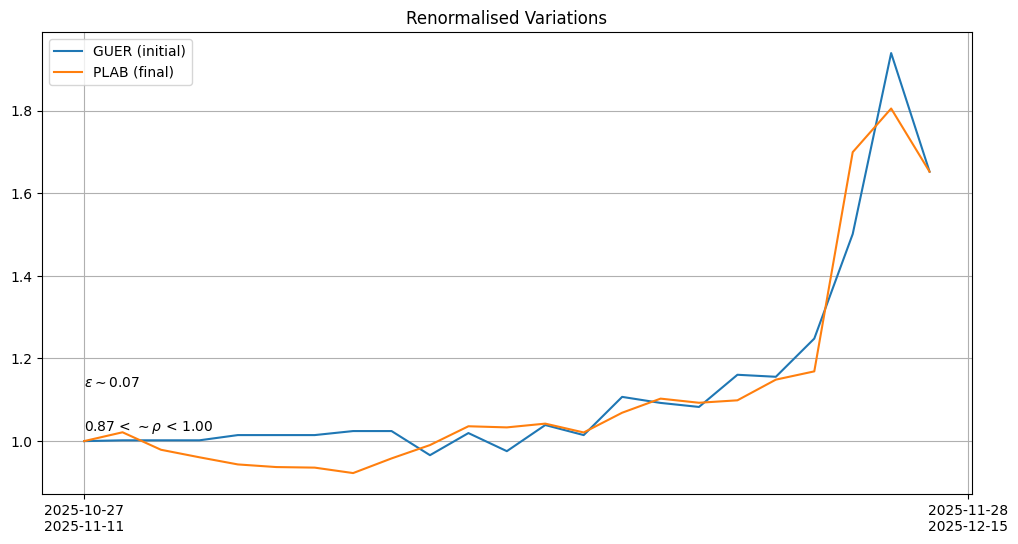

Internalized rate of return: ~584566% (GUER) and ~29909% (PLAB).


In [4]:
plt.figure(figsize=(12, 6))
plt.title("Renormalised Variations")
plt.plot(_x, label="GUER (initial)")
plt.plot(_y, label="PLAB (final)")
# plt.text(0, np.mean(_x) * 1.1, f"$\\rho \sim {100 * COEF:.2f}$%")
plt.text(0, np.mean(_x), f"$\\varepsilon \sim {e:.2f}$")
plt.text(
    0,
    np.median(_x),
    f"{(COEF - delta):.2f} < $\sim\\rho$ < {(min(1, COEF + delta)):.2f}",
)  # intrasignal error
plt.xticks([0, len(_x)], idxs)
plt.legend()
plt.grid()
plt.show()

irrx, irry = (X.iloc[-1] / X.iloc[0]) ** (250 / (X.shape[0] - 1)) - 1, (
    Y.iloc[-1] / Y.iloc[0]
) ** (250 / (Y.shape[0] - 1)) - 1

irrx, irry = float(irrx), float(irry)

out_string = f"Internalized rate of return: ~{100*irrx:.0f}% (GUER) and ~{100 * irry:.0f}% (PLAB)."
print(out_string)

## RELATIVE FREQUENCY

In [5]:
start = "2025-01-01"
end = None

symbols = ["GUER", "PLAB"]

DATA = yf.download(symbols, start=start, end=end)["Close"]

spread_months = np.linspace(0, 1, 11)
spread_days = spread_months * 250 / 12
spread_days = spread_days.astype(int)

coefs = []
dates = []

for i in range(DN.shape[0] - spread_days[-1] - window):
    x = DN.iloc[i : i + window, 0]
    for spread in spread_days:
        y = DN.iloc[i + spread : i + window + spread, 1]
        coef = np.cov(x, y) / (np.std(x) * np.std(y))
        coef = float(coef[1][0])
        coefs.append(coef)

coefs = np.array(coefs)

mean_, std_ = float(np.mean(coefs)), float(np.std(coefs))

print(f"Mean: {mean_:.4f}\nStandard deviation: {std_:.4f}")

[*********************100%***********************]  2 of 2 completed


Mean: 0.0386
Standard deviation: 0.4084


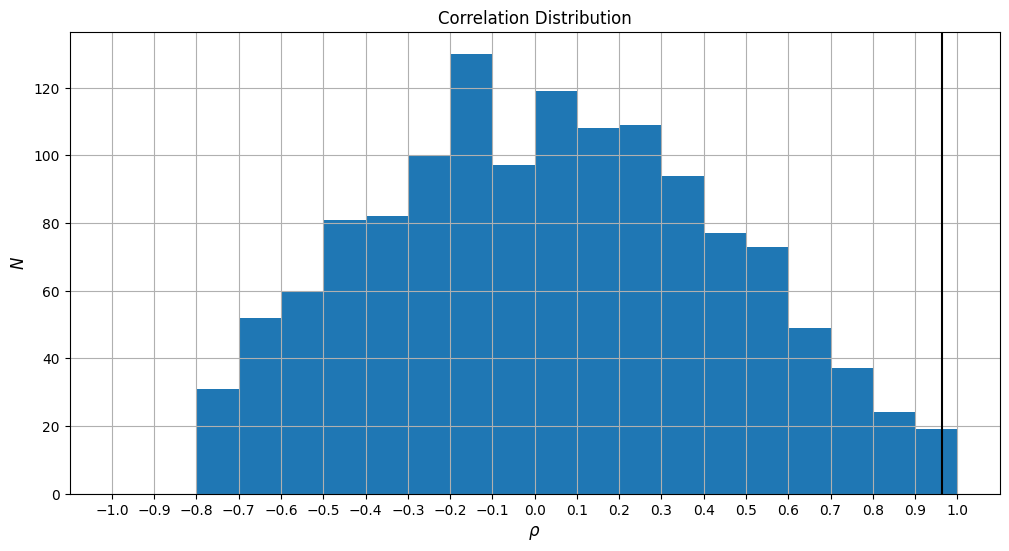

Relative frequency (approximate): 1.42%
Relative frequency (precise): 0.15%


In [6]:
plt.figure(figsize=(12, 6))
bins = np.linspace(-1, 1, 21)
x, y, z = plt.hist(coefs, bins=bins)
plt.title("Correlation Distribution", fontsize=12)
plt.ylabel("$N$", fontsize=12)
plt.xlabel("$\\rho$", fontsize=12)
plt.xticks(bins)
plt.grid()
plt.axvline(COEF, color="k")
plt.show()

print(f"Relative frequency (approximate): {100 * x[-1] / len(coefs):.2f}%")
print(
    f"Relative frequency (precise): {100 * (1 - (COEF > coefs).sum() / len(coefs)):.2f}%"
)

## INTRASIGNAL DEVIATIONS

In [7]:
N = 13
Xmn = 10**2 * np.abs(X.pct_change()).mean()
X2mn = 10**4 * np.abs(X.pct_change() ** 2).mean()
AX = geom_(Xmn, X2mn)
# AX

In [8]:
Ymn = 10**2 * np.abs(Y.pct_change()).mean()
Y2mn = 10**4 * np.abs(Y.pct_change() ** 2).mean()
AY = geom_(Ymn, Y2mn)
# AY

In [9]:
A = (AX, AY)
AA = axis_(A, False)  # arithmetic
AG = axis_(A)  # geometric
A = (AA, AG)
A = axis_(A, False)  # arithmentic arithmetic
AAGA = (A + AA + AG) / 3  # (arithmentic arithmetic arithmetic geometric) arithmetic
AAGG = (A * AA * AG) ** (
    1 / 3
)  # (arithmentic arithmetic arithmetic geometric) geometric
_A = [A, AA, AG, AAGA, AAGG]
# _A

## INTERSIGNAL DEVIATIONS

In [10]:
x, y = np.array(X), np.array(Y)

x = (x - 1) * (y[-1] - 1) / (x[-1] - 1) + 1

Emn = 10**2 * np.mean(np.abs(x - y))
E2mn = 10**4 * np.mean((x - y) ** 2)

_E = geom_(Emn, E2mn)
# _E

## INTER INTRA SIGNAL DEVIATIONS

In [11]:
CC = [100 * (_E / A_ - 1) for A_ in _A]
CC.append(np.mean(CC, axis=0))

In [12]:
out_string = (
    f"Per cent cut (Absolute): {np.mean([cc[:len(cc) // 2] for cc in CC]):.0f}%"
)
out_string += " +/- "
out_string += f"{(np.mean([A_[:len(A_) // 2] for A_ in _A]) ** 2 + _E[:len(_E) // 2][0] ** 2) ** 0.25:.1f}%"  # ad hoc
print(out_string)

Per cent cut (Absolute): -11% +/- 3.2%


In [13]:
out_string = f"Per cent cut (Squared): {np.mean([cc[len(cc) // 2:] for cc in CC]):.0f}%"
out_string += " +/- "
out_string += f"{(np.mean([A_[len(A_) // 2:] for A_ in _A]) ** 2 + _E[len(_E) // 2:][0] ** 2) ** 0.25:.1f}%"  # ad hoc
print(out_string)

Per cent cut (Squared): -38% +/- 11.2%


# C.I. and G.S.P.C.

In [14]:
N = 40

symbols = [
    "BA",
    "INTC",
    "LPLA",
    "MU",
]

start = "2024-06-28"
end = "2024-10-01"

S = yf.download(symbols, start=start, end=end)["Close"]
S_N = S / S.iloc[0]

MEAN_N = S_N.mean(axis=1)
X = MEAN_N.iloc[: N + 1]

[*********************100%***********************]  4 of 4 completed


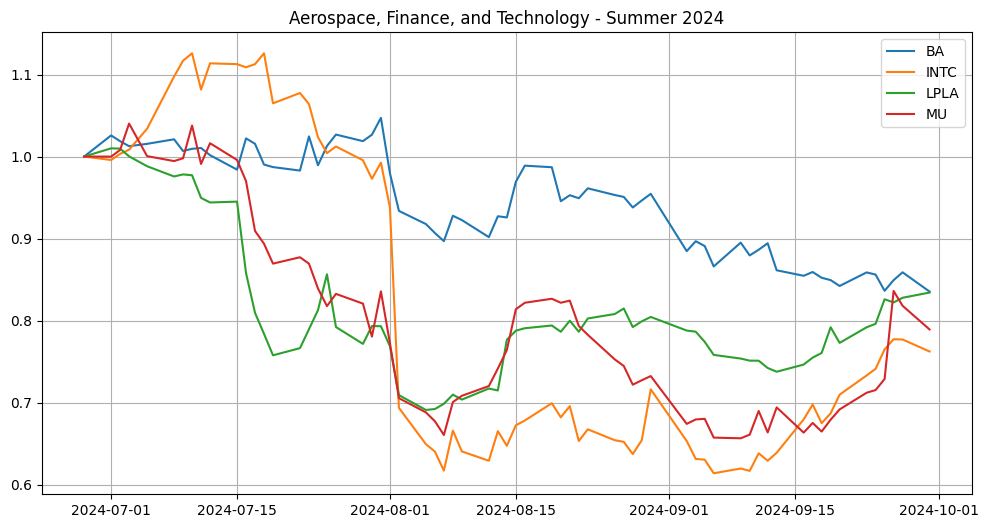

In [15]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(S_N, label=S_N.columns)
plt.title("Aerospace, Finance, and Technology - Summer 2024", fontsize=12)
plt.grid()
plt.legend()
plt.show()

In [16]:
# # IRR = (MEAN_N.loc["2024-08-07"] / MEAN_N.loc["2024-07-01"]) ** (251 / (MEAN_N.index.get_loc("2024-08-07") - MEAN_N.index.get_loc("2024-07-01"))) - 1
IRR = (MEAN_N.loc["2024-08-07"] / MEAN_N.loc["2024-07-10"]) ** (
    251 / (MEAN_N.index.get_loc("2024-08-07") - MEAN_N.index.get_loc("2024-07-10"))
) - 1
IRR = float(IRR)
print(
    f"Mean of {symbols} peak decline\ninternalized rate of return: {100*IRR:.0f}% (approx.)"
)

Mean of ['BA', 'INTC', 'LPLA', 'MU'] peak decline
internalized rate of return: -99% (approx.)


#### GSPC - Spring, 2025.

In [17]:
idx = "^GSPC"
start = "2025-02-01"
end = "2025-05-01"
IDX = yf.download(idx, start=start, end=end)["Close"]
IDX_N = IDX / IDX.iloc[0]
Y = IDX_N["^GSPC"].iloc[: N + 1]

[*********************100%***********************]  1 of 1 completed


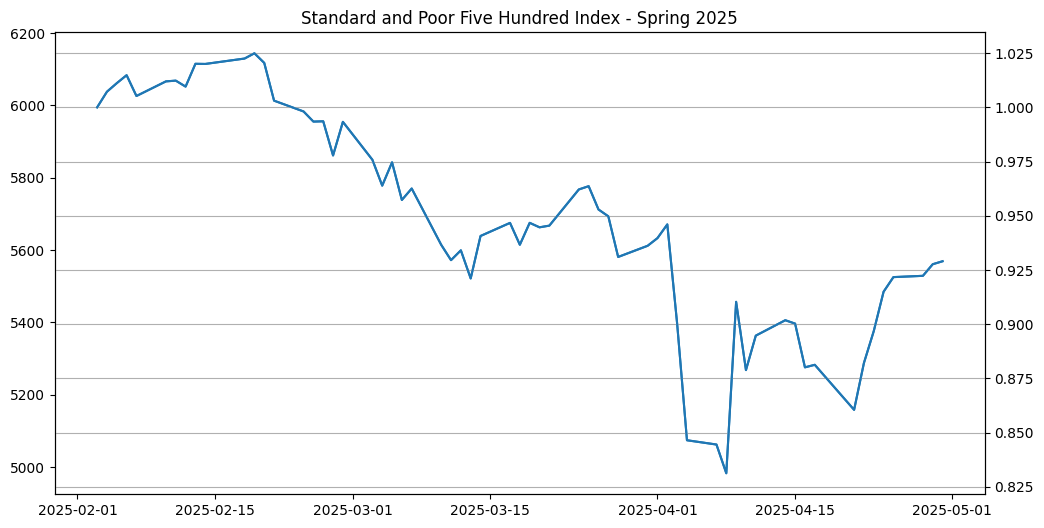

In [18]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(IDX, label=idx)
ax2 = ax1.twinx()
ax2.plot(IDX_N)
plt.grid()
plt.title("Standard and Poor Five Hundred Index - Spring 2025", fontsize=12)
plt.show()

In [19]:
IRR = (IDX.loc["2025-04-07"] / IDX.loc["2025-02-19"]) ** (
    251 / (IDX.index.get_loc("2025-04-07") - IDX.index.get_loc("2025-02-19"))
) - 1
IRR = float(IRR.iloc[0])
print(f"{idx} peak decline internalized rate of return: {100*IRR:.0f}% (approx.)")

^GSPC peak decline internalized rate of return: -77% (approx.)


## COEF

In [20]:
x_, y_ = np.array(X), np.array(Y)
x_ = (x_ - 1) * (y_[-1] - 1) / (x_[-1] - 1) + 1
COEF = np.corrcoef(x_, y_)[1][0]
e = np.mean((y_ - x_) ** 2) ** 0.5
delta = (
    np.abs(X.pct_change()).mean() ** 2 + np.abs(Y.pct_change()).mean() ** 2
) ** 0.5  # intraday is better

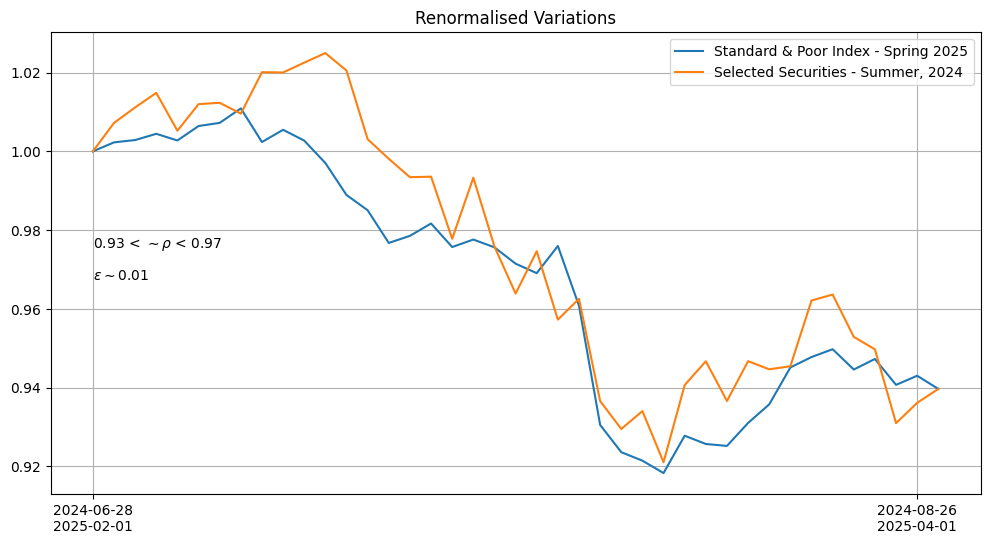

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(x_, label="Standard & Poor Index - Spring 2025")
plt.plot(y_, label="Selected Securities - Summer, 2024")
plt.grid()
plt.title("Renormalised Variations", fontsize=12)
# plt.text(0, np.median(x_), f"$\\rho \sim ${100 * COEF:.1f}%")
plt.text(
    0,
    np.median(x_),
    f"{(COEF - delta):.2f} < $\sim\\rho$ < {(min(1, COEF + delta)):.2f}",
)  # should use intrasignal error
plt.text(0, np.mean(x_), f"$\epsilon \sim ${e:.2f}")
plt.xticks([0, N - 1], ["2024-06-28\n2025-02-01", "2024-08-26\n2025-04-01"])
# plt.ylim([0.6, 1.1])
plt.legend()
plt.show()

In [22]:
start = "2024-01-01"
end = None

symbols = ["BA", "INTC", "LPLA", "MU"]

S_N = yf.download(symbols, start=start, end=end)["Close"]

idx = "^GSPC"
IDX = yf.download(idx, start=start, end=end)["Close"]
IDX_N = IDX / IDX.iloc[0]

spread_months = np.linspace(5, 10, 101)
spread_days = spread_months * 250 / 12
spread_days = spread_days.astype(int)

window = N

coefs = []
dates = []

for i in range(IDX_N.shape[0] - spread_days[-1] - window):
    x = (S_N.iloc[i : i + window] / S_N.iloc[i]).mean(axis=1)
    for spread in spread_days:
        y = (
            IDX_N["^GSPC"].iloc[i + spread : i + spread + window]
            / IDX_N["^GSPC"].iloc[i + spread]
        )
        coef = np.corrcoef(x, y)
        coef = float(coef[1][0])
        coefs.append(coef)

coefs = np.array(coefs)

mean_, std_ = float(np.mean(coefs)), float(np.std(coefs))

print(f"Mean: {mean_:.4f}\nStandard deviation: {std_:.4f}")

[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  1 of 1 completed


Mean: 0.0834
Standard deviation: 0.4747


## RELATIVE FREQUENCY

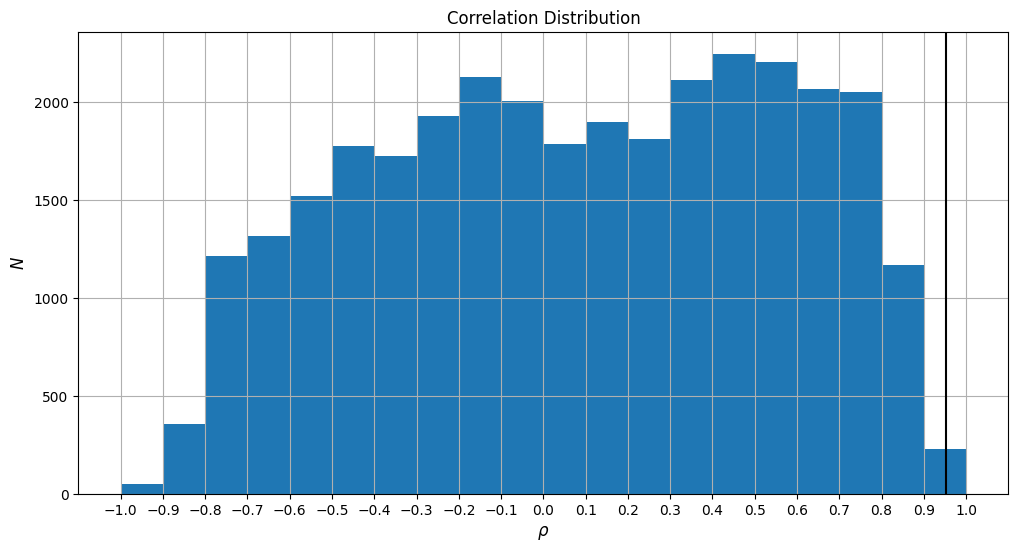

Relative frequency (approximate): 0.73%
Relative frequency (precise): 0.02%


In [23]:
plt.figure(figsize=(12, 6))
bins = np.linspace(-1, 1, 21)
x, y, z = plt.hist(coefs, bins=bins)
plt.title("Correlation Distribution", fontsize=12)
plt.ylabel("$N$", fontsize=12)
plt.xlabel("$\\rho$", fontsize=12)
plt.xticks(bins)
plt.grid()
plt.axvline(COEF, color="k")
plt.show()

print(f"Relative frequency (approximate): {100 * x[-1] / len(coefs):.2f}%")
print(
    f"Relative frequency (precise): {100 * (1 - (COEF > coefs).sum() / len(coefs)):.2f}%"
)

## INTRASIGNAL DEVIATIONS

In [24]:
Xmn = 10**2 * np.abs(X.pct_change()).mean()
X2mn = 10**4 * np.abs(X.pct_change() ** 2).mean()
AX = geom_(Xmn, X2mn)
# AX

In [25]:
Ymn = 10**2 * np.abs(Y.pct_change()).mean()
Y2mn = 10**4 * np.abs(Y.pct_change() ** 2).mean()
AY = geom_(Ymn, Y2mn)
# AY

In [26]:
A = (AX, AY)
AA = axis_(A, False)  # arithmetic
AG = axis_(A)  # geometric
A = (AA, AG)
A = axis_(A, False)  # arithmentic arithmetic
AAGA = (A + AA + AG) / 3  # (arithmentic arithmetic arithmetic geometric) arithmetic
AAGG = (A * AA * AG) ** (
    1 / 3
)  # (arithmentic arithmetic arithmetic geometric) geometric
_A = [A, AA, AG, AAGA, AAGG]
# _A

## INTERSIGNAL DEVIATIONS

In [27]:
x, y = np.array(X), np.array(Y)

x = (x - 1) * (y[-1] - 1) / (x[-1] - 1) + 1

Emn = 10**2 * np.mean(np.abs(x - y))
E2mn = 10**4 * np.mean((x - y) ** 2)

_E = geom_(Emn, E2mn)
# _E

## INTER INTRA SIGNAL DEVIATIONS

In [28]:
CC = [100 * (_E / A_ - 1) for A_ in _A]
CC.append(np.mean(CC, axis=0))

In [29]:
out_string = (
    f"Per cent cut (Absolute): {np.mean([cc[:len(cc) // 2] for cc in CC]):.0f}%"
)
out_string += " +/- "
out_string += f"{(np.mean([A_[:len(A_) // 2] for A_ in _A]) ** 2 + _E[:len(_E) // 2][0] ** 2) ** 0.25:.1f}%"  # ad hoc
print(out_string)

Per cent cut (Absolute): -27% +/- 1.4%


In [30]:
out_string = f"Per cent cut (Squared): {np.mean([cc[len(cc) // 2:] for cc in CC]):.0f}%"
out_string += " +/- "
out_string += f"{(np.mean([A_[len(A_) // 2:] for A_ in _A]) ** 2 + _E[len(_E) // 2:][0] ** 2) ** 0.25:.1f}%"  # ad hoc
print(out_string)

Per cent cut (Squared): -54% +/- 1.9%
